# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.


In [10]:
df = pd.read_csv('../ex02/dayofweek.csv')

2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.

In [11]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)



3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.


In [12]:

print("Class distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test set")
print(y_test.value_counts(normalize=True))


Class distribution in training set:
dayofweek
3    0.232196
6    0.212908
1    0.164688
5    0.160237
2    0.092730
0    0.077893
4    0.059347
Name: proportion, dtype: float64

Class distribution in test set
dayofweek
3    0.245562
6    0.204142
5    0.162722
1    0.153846
0    0.091716
4    0.071006
2    0.071006
Name: proportion, dtype: float64


4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [13]:

X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

print("\nClass distribution in training set (with stratification):")
print(y_train_strat.value_counts(normalize=True))
print("\nClass distribution in test set (with stratification):")
print(y_test_strat.value_counts(normalize=True))



Class distribution in training set (with stratification):
dayofweek
3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: proportion, dtype: float64

Class distribution in test set (with stratification):
dayofweek
3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: proportion, dtype: float64


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.


In [14]:
models = {
    'Logistic Regression': LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear'),
    'SVC (Linear)': OneVsRestClassifier(SVC(kernel='linear', random_state=21, probability=True)),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=21),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
}

results = {}
for name, model in models.items():
    model.fit(X_train_strat, y_train_strat)
    y_pred = model.predict(X_test_strat)
    acc = accuracy_score(y_test_strat, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.5f}")

Logistic Regression Accuracy: 0.61538
SVC (Linear) Accuracy: 0.61834
Decision Tree Accuracy: 0.52959
Random Forest Accuracy: 0.92899


### a. Logreg

**Logistic Regression**

Accuracy in ex03: **0.61538** 

Accuracy in ex02: **0.6216**

### b. SVM

**SVC (Linear)** 

Accuracy in ex03: **0.61834** 

Accuracy in ex02: **0.6127**

### c. Decision tree

**Decision Tree**

Accuracy in ex03: **0.52959** 

Accuracy in ex02: **0.5516**

### d. Random forest

**Random Forest**

Accuracy in ex03: **0.92899** 

Accuracy in ex02: **1.0000**

**QUESTIONS**

- Did all the models show the similar values of the metric?

**no**, all different

- Which one has the largest difference comparing the current exercise and the previous? 

**random forest**

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

In [15]:
print("\nCross-validation (cv=10):")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10)
    cv_mean = scores.mean()
    cv_std = scores.std()
    cv_results[name] = (cv_mean, cv_std)
    print(f"{name}: {cv_mean:.4f} (±{cv_std:.4f})")


Cross-validation (cv=10):
Logistic Regression: 0.4529 (±0.1696)
SVC (Linear): 0.4423 (±0.1414)
Decision Tree: 0.3884 (±0.1184)
Random Forest: 0.6608 (±0.1746)


### a. Logreg

the mean accuracy is **0.4529**

standard deviation is **(±0.1696)**

### b. SVM

the mean accuracy is **0.4423**

standard deviation is **±0.1414**

### c. Decision tree

the mean accuracy is **0.3884**

standard deviation is **±0.1184**

### d. Random forest

the mean accuracy is **0.6608**

standard deviation is **±0.1746**

## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [16]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 25, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=21)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_strat, y_train_strat)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_params = grid_search.best_params_
final_model = RandomForestClassifier(**best_params, random_state=21)
final_model.fit(X_train_strat, y_train_strat)

Best parameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.9028087567121025


RandomForestClassifier(max_depth=25, n_estimators=200, random_state=21)

In [17]:
y_pred_final = final_model.predict(X_test_strat)
final_acc = accuracy_score(y_test_strat, y_pred_final)
print(f"Final model accuracy on test data: {final_acc:.4f}")

Final model accuracy on test data: 0.9320


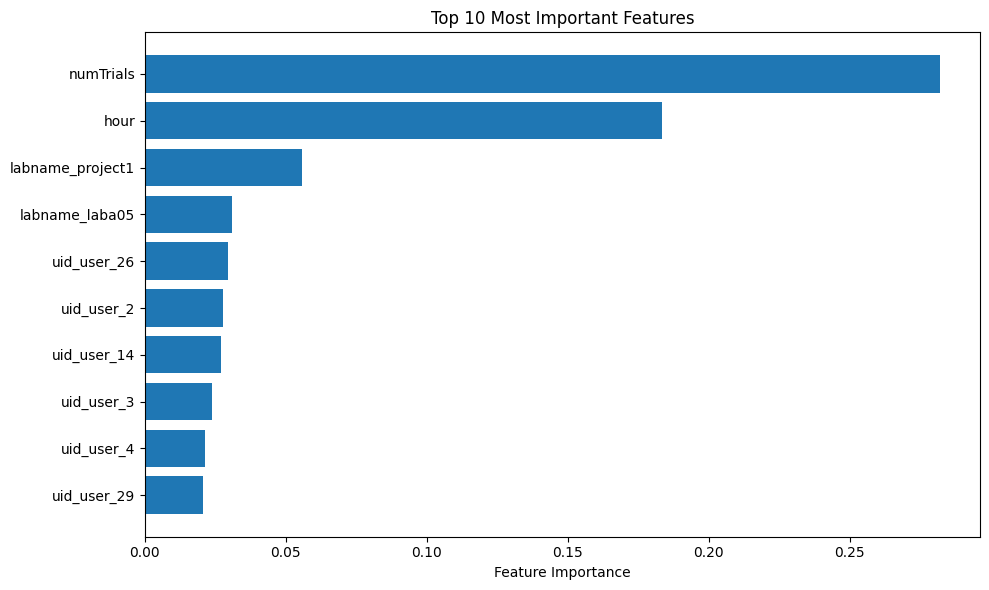

In [18]:
feature_importance = final_model.feature_importances_
indices = np.argsort(feature_importance)[-10:]
features = X.columns[indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), feature_importance[indices], align='center')
plt.yticks(range(len(indices)), features)
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

In [19]:
joblib.dump(final_model, 'best_model.joblib')
print("Model saved as 'best_model.joblib'")

Model saved as 'best_model.joblib'


In [20]:
loaded_model = joblib.load('best_model.joblib')
y_pred_loaded = loaded_model.predict(X_test_strat)
loaded_acc = accuracy_score(y_test_strat, y_pred_loaded)
print(f"Loaded model accuracy: {loaded_acc:.4f}")

Loaded model accuracy: 0.9320
